<a href="https://colab.research.google.com/github/Sujal0304/RetentionOS-AI-Customer-Retention-Revenue-Intelligence-Platform-/blob/main/RetentionOS%3A%20AI%20Customer%20Retention%20Revenue%20Intelligence%20Platform%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retention Budget Allocator

# 1. Setup

In [ ]:
!pip install -q openai

import pandas as pd
import numpy as np
import os

os.makedirs("/content/outputs", exist_ok=True)


# 2. Data Cleaning

In [ ]:
from google.colab import files
uploaded = files.upload()

RAW_PATH = "/content/Telco_customer_churn.xlsx"
fname = list(uploaded.keys())[0]
os.rename(fname, RAW_PATH)


Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [ ]:
df = pd.read_excel(RAW_PATH)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Monthly Charges"])
df["churn"] = (df["Churn Label"] == "Yes").astype(int)

print(f"Rows: {len(df)} | Churn rate: {df['churn'].mean():.2%}")


Rows: 7043 | Churn rate: 26.54%


In [ ]:
assert df["CustomerID"].is_unique, "Duplicate customer IDs found"
assert df["Total Charges"].isnull().sum() == 0, "Unhandled nulls in Total Charges"
assert df["Churn Label"].isin(["Yes", "No"]).all(), "Unexpected churn label values"
assert (df["Tenure Months"] >= 0).all(), "Negative tenure found"

print("All validation checks passed")


All validation checks passed


# 3. EDA / Visualization

/tmp/ipykernel_3690/4291894655.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby("tenure_bucket")["churn"].mean()


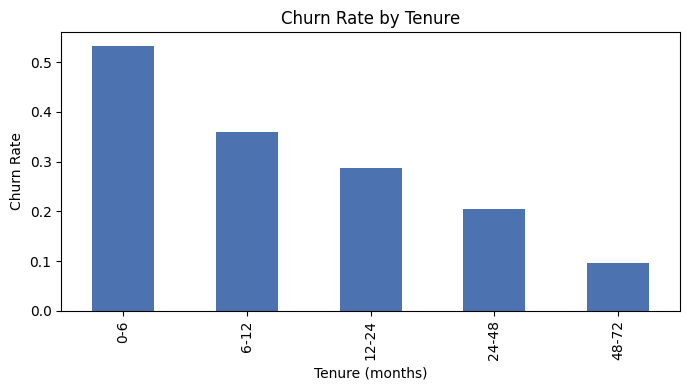

In [ ]:
import matplotlib.pyplot as plt

df["tenure_bucket"] = pd.cut(
    df["Tenure Months"], bins=[0,6,12,24,48,72],
    labels=["0-6","6-12","12-24","24-48","48-72"]
)
tenure_churn = df.groupby("tenure_bucket")["churn"].mean()

plt.figure(figsize=(7,4))
tenure_churn.plot(kind="bar", color="#4C72B0")
plt.title("Churn Rate by Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure (months)")
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

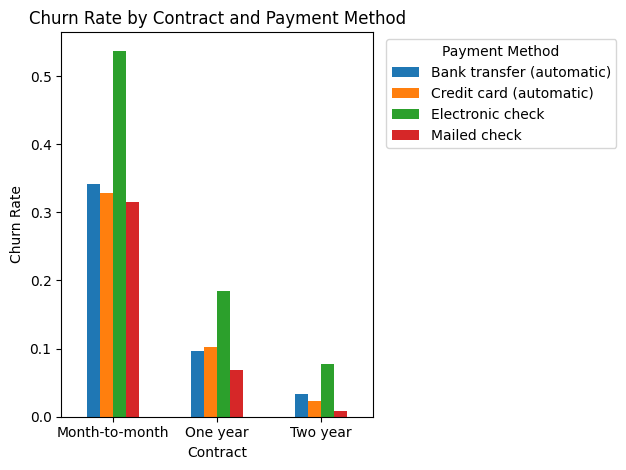

In [ ]:
payment_churn = df.groupby(["Contract","Payment Method"])["churn"].mean().unstack()

plt.figure(figsize=(8,4))
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Contract and Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


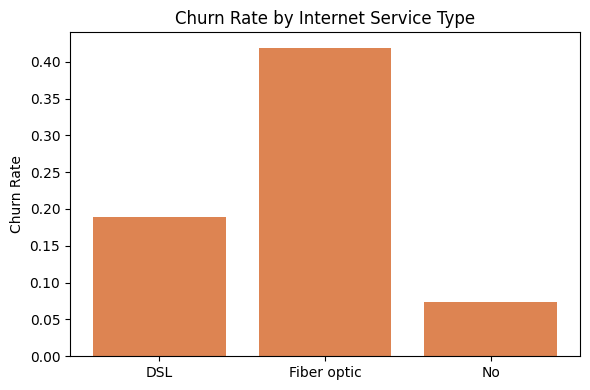

                  Monthly Charges  churn
Internet Service                        
DSL                         58.10   0.19
Fiber optic                 91.50   0.42
No                          21.08   0.07


In [ ]:
internet_churn = df.groupby("Internet Service")[["Monthly Charges","churn"]].mean()

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.bar(internet_churn.index, internet_churn["churn"], color="#DD8452")
ax1.set_ylabel("Churn Rate")
ax1.set_title("Churn Rate by Internet Service Type")
plt.tight_layout()
plt.show()

print(internet_churn.round(2))


# 4. Preprocessing

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

binary_cols = ["Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"]
for c in binary_cols:
    df[c] = df[c].map({"Yes": 1, "No": 0}).fillna(0)

numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges"] + binary_cols
categorical_cols = ["Gender", "Multiple Lines", "Internet Service", "Online Security",
    "Online Backup", "Device Protection", "Tech Support", "Streaming TV",
    "Streaming Movies", "Contract", "Payment Method"]

X = df[numeric_cols + categorical_cols]
y = df["churn"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

print(f"Numeric features: {len(numeric_cols)} | Categorical features: {len(categorical_cols)}")


Numeric features: 8 | Categorical features: 11


# 5. Model Building and Validation

### 5.1 Cross-validated comparison
Each model is scored 5 times on different held-out slices of the data
(5-fold cross-validation), instead of just once, for a more reliable picture.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipe_gb = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score returns one AUC score PER FOLD (5 separate numbers).
# .mean() is plain averaging of those 5 numbers into one summary score.
# .std() shows how much the score varies across folds (a consistency check).
scores_lr = cross_val_score(pipe_lr, X, y, cv=cv, scoring="roc_auc")
scores_gb = cross_val_score(pipe_gb, X, y, cv=cv, scoring="roc_auc")

print("Logistic Regression fold scores:", scores_lr.round(4))
print("Gradient Boosting fold scores:  ", scores_gb.round(4))
print()
print(f"Logistic Regression: mean AUC={scores_lr.mean():.4f}, std={scores_lr.std():.4f}")
print(f"Gradient Boosting:   mean AUC={scores_gb.mean():.4f}, std={scores_gb.std():.4f}")


Logistic Regression fold scores: [0.8604 0.8419 0.8611 0.8562 0.8686]
Gradient Boosting fold scores:   [0.8559 0.8556 0.8674 0.8583 0.87  ]

Logistic Regression: mean AUC=0.8577, std=0.0088
Gradient Boosting:   mean AUC=0.8614, std=0.0061


### 5.2 Statistical test
A paired t-test checks whether the AUC difference between the two models
is real, or just random variation across folds. A p-value below 0.05 would
mean the difference is statistically significant.


In [ ]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(scores_gb, scores_lr)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant difference -- the better-scoring model is genuinely better")
else:
    print("No statistically significant difference -- safe to pick the simpler, more interpretable model")


t-statistic: 1.256
p-value: 0.2774
No statistically significant difference -- safe to pick the simpler, more interpretable model


### 5.3 Train the final model

In [ ]:
final_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
final_pipeline.fit(X, y)

df["churn_probability"] = final_pipeline.predict_proba(X)[:, 1].round(4)

import joblib
joblib.dump(final_pipeline, "/content/outputs/churn_pipeline.pkl")
print("Pipeline trained and saved")


Pipeline trained and saved


# 6. Health Score and Segmentation

In [ ]:
def compute_health_score(churn_prob, tenure_months, cltv, contract_type):
    tenure_score = np.log1p(tenure_months) / np.log1p(72) * 100

    cltv_min, cltv_max = cltv.min(), cltv.max()
    cltv_score = ((cltv - cltv_min) / (cltv_max - cltv_min) * 100).clip(0, 100)

    contract_score_map = {"Month-to-month": 0, "One year": 50, "Two year": 100}
    contract_score = contract_type.map(contract_score_map).fillna(0)

    health = (
        0.40 * (1 - churn_prob) * 100
        + 0.25 * tenure_score
        + 0.20 * cltv_score
        + 0.15 * contract_score
    )
    return health.round(1)

df["health_score"] = compute_health_score(
    df["churn_probability"], df["Tenure Months"], df["CLTV"], df["Contract"]
)
print(df["health_score"].describe())


count    7043.000000
mean       57.220900
std        24.603814
min         8.400000
25%        35.600000
50%        56.100000
75%        80.100000
max        99.900000
Name: health_score, dtype: float64


In [ ]:
def assign_segment(health_score, churn_prob, cltv, cltv_median):
    segments = []
    for h, p, c in zip(health_score, churn_prob, cltv):
        if h >= 70:
            segments.append("Champion")
        elif h < 40 and c >= cltv_median:
            segments.append("At-risk, high value")
        elif h < 40 and c < cltv_median:
            segments.append("At-risk, low value")
        elif p > 0.6:
            segments.append("Recoverable")
        else:
            segments.append("Stable")
    return segments

cltv_median = df["CLTV"].median()
df["segment"] = assign_segment(df["health_score"], df["churn_probability"], df["CLTV"], cltv_median)
print(df["segment"].value_counts())


segment
Champion               2523
Stable                 1862
At-risk, low value     1582
At-risk, high value     593
Recoverable             483
Name: count, dtype: int64


# 7. Budget Allocator

In [ ]:
df["expected_value_saved"] = (df["churn_probability"] * df["CLTV"]).round(2)

def allocate_budget(scored_df, budget_n):
    active = scored_df[scored_df["Churn Label"] == "No"].copy()
    active = active.sort_values("expected_value_saved", ascending=False).reset_index(drop=True)
    active["rank"] = active.index + 1
    allocated = active.head(budget_n).copy()
    ev_captured = allocated["expected_value_saved"].sum()
    ev_total = active["expected_value_saved"].sum()
    return allocated, ev_captured, ev_total

budget_n = 50
allocated, ev_captured, ev_total = allocate_budget(df, budget_n)
print(f"Budget: {budget_n} | EV captured: ${ev_captured:,.0f} ({ev_captured/ev_total:.1%} of all at-risk value)")
allocated[["CustomerID","Contract","Tenure Months","CLTV","health_score","expected_value_saved","rank"]].head(10)


Budget: 50 | EV captured: $242,506 (3.6% of all at-risk value)


,CustomerID,Contract,Tenure Months,CLTV,health_score,expected_value_saved,rank
0,0187-QSXOE,Month-to-month,7,5711,31.8,5253.55,1
1,2371-JQHZZ,Month-to-month,24,5886,40.5,5228.53,2
2,6583-KQJLK,Month-to-month,15,5868,37.8,5215.48,3
3,2876-GZYZC,Month-to-month,13,5886,37.4,5184.39,4
4,5995-SNNEW,Month-to-month,23,5883,40.6,5175.28,5
5,2688-BHGOG,Month-to-month,9,5811,35.5,5070.10,6
6,9957-YODKZ,Month-to-month,6,5611,31.3,5057.76,7
7,7577-SWIFR,Month-to-month,1,5579,23.7,5055.13,8
8,1628-BIZYP,Month-to-month,1,5754,25.8,5029.00,9
9,8541-QVFKM,Month-to-month,8,5777,34.8,5018.48,10


In [ ]:
for b in [20, 50, 100, 200, 500]:
    a, evc, evt = allocate_budget(df, b)
    print(f"Budget={b:4d} | EV captured=${evc:>12,.0f} | avg EV per customer=${evc/b:,.0f}")


Budget=  20 | EV captured=$     100,402 | avg EV per customer=$5,020
Budget=  50 | EV captured=$     242,506 | avg EV per customer=$4,850
Budget= 100 | EV captured=$     462,465 | avg EV per customer=$4,625
Budget= 200 | EV captured=$     870,170 | avg EV per customer=$4,351
Budget= 500 | EV captured=$   1,921,855 | avg EV per customer=$3,844


# 8. AI Explanation (Groq)

This step writes a short, plain-language note for each customer in the
budget list -- the kind of note a CSM or VP could read in 10 seconds,
with no technical terms.

It does two things differently from a generic AI explain:
1. It looks at customers who already left with a SIMILAR profile, and pulls
   their most common real reason for leaving -- so the suggested action
   matches the actual likely problem, not just "give them a longer contract"
   every time.
2. The output is written for a non-technical reader -- no "churn probability",
   no "expected value", no percentages thrown at the reader without context.

Setup before running: click the key icon on the left sidebar -> Secrets ->
add a secret named GROQ_API_KEY with your key from console.groq.com ->
turn on notebook access.


In [ ]:
# We no longer pre-compute a priority tier ourselves.
# The AI will decide priority directly from the raw numbers below
# (Health Score, Revenue, Revenue at Risk, Churn Risk, and context columns).
# We keep "rank" only as a reference for our own checking, not shown to the AI.

print("Rank already exists from the allocator step. Moving straight to building the analyst table.")
allocated[["CustomerID","rank","expected_value_saved"]].head(10)

Rank already exists from the allocator step. Moving straight to building the analyst table.


,CustomerID,rank,expected_value_saved
0,0187-QSXOE,1,5253.55
1,2371-JQHZZ,2,5228.53
2,6583-KQJLK,3,5215.48
3,2876-GZYZC,4,5184.39
4,5995-SNNEW,5,5175.28
5,2688-BHGOG,6,5070.10
6,9957-YODKZ,7,5057.76
7,7577-SWIFR,8,5055.13
8,1628-BIZYP,9,5029.00
9,8541-QVFKM,10,5018.48


In [ ]:
# Build the table the AI will reason over.
# "Revenue at Risk" = churn_probability x CLTV (dollars likely to be lost).
# "Revenue" = the customer's actual lifetime value (CLTV), full size of the account.
# Both are given so the AI can judge priority itself -- a customer can have
# high Revenue at Risk but low total Revenue, or vice versa, and that
# distinction matters for how a manager should prioritize.

analyst_table = allocated.rename(columns={
    "churn_probability": "Churn Risk",
    "health_score": "Health Score",
    "expected_value_saved": "Revenue at Risk",
    "CLTV": "Revenue",
}).copy()

analyst_columns = [
    "CustomerID", "Churn Risk", "Health Score", "Revenue", "Revenue at Risk",
    "Tenure Months", "Contract", "Internet Service", "Payment Method", "Monthly Charges"
]
analyst_table = analyst_table[analyst_columns]
analyst_table.head(10)

,CustomerID,Churn Risk,Health Score,Revenue,Revenue at Risk,Tenure Months,Contract,Internet Service,Payment Method,Monthly Charges
0,0187-QSXOE,0.9199,31.8,5711,5253.55,7,Month-to-month,Fiber optic,Electronic check,89.00
1,2371-JQHZZ,0.8883,40.5,5886,5228.53,24,Month-to-month,Fiber optic,Electronic check,93.00
2,6583-KQJLK,0.8888,37.8,5868,5215.48,15,Month-to-month,Fiber optic,Electronic check,94.65
3,2876-GZYZC,0.8808,37.4,5886,5184.39,13,Month-to-month,Fiber optic,Electronic check,85.95
4,5995-SNNEW,0.8797,40.6,5883,5175.28,23,Month-to-month,Fiber optic,Electronic check,104.45
5,2688-BHGOG,0.8725,35.5,5811,5070.10,9,Month-to-month,Fiber optic,Electronic check,79.55
6,9957-YODKZ,0.9014,31.3,5611,5057.76,6,Month-to-month,Fiber optic,Electronic check,80.80
7,7577-SWIFR,0.9061,23.7,5579,5055.13,1,Month-to-month,Fiber optic,Electronic check,89.25
8,1628-BIZYP,0.8740,25.8,5754,5029.00,1,Month-to-month,Fiber optic,Electronic check,85.00
9,8541-QVFKM,0.8687,34.8,5777,5018.48,8,Month-to-month,Fiber optic,Electronic check,73.50


In [ ]:
!pip install -q openai

from openai import OpenAI
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = OpenAI(api_key=GROQ_API_KEY, base_url="https://api.groq.com/openai/v1")
GROQ_MODEL = "llama-3.3-70b-versatile"


In [ ]:
import json

PROMPT_TEMPLATE = (
    "You are a customer success analyst. You are given real data about one "
    "customer below. Based only on this data, do three things for a "
    "non-technical manager:\n"
    "1. Decide a priority label for this customer: P1 (act this week), "
    "P2 (act soon), or P3 (low urgency). Base this on how much Revenue is at "
    "stake and how at-risk they are, weighed together -- not on Revenue at "
    "Risk alone. Note: Revenue at Risk is the amount we stand to lose if "
    "nothing is done -- not a guaranteed savings amount.\n"
    "2. In one sentence, explain your read on why this customer is at risk, "
    "based on the patterns in their data (tenure, contract, internet "
    "service, payment method, charges).\n"
    "3. In one sentence, suggest one specific, practical action, matched to "
    "your reasoning.\n\n"
    "Rules:\n"
   "- Do not use technical words like 'probability', 'score', or "
    "'percentage points'.\n"
    "- Always mention the actual dollar amount (Revenue or Revenue at Risk) "
    "somewhere in your Reason or Action sentence, in plain language "
    "(for example: 'this account is worth around $X').\n"
    "- Only reason from the facts given. Do not invent facts not listed "
    "below (for example, do not assume anything about support calls or "
    "complaints unless stated).\n"
    "- Format your answer as exactly three lines: Priority, Reason, Action.\n\n"
    "Customer data:\n{customer_data}"
)

def build_customer_data_block(row):
    labels = {
        "Churn Risk": "Churn Risk",
        "Health Score": "Health Score",
        "Revenue": "Revenue",
        "Revenue at Risk": "Revenue at Risk (amount that could be lost, not guaranteed savings)",
        "Tenure Months": "Tenure Months",
        "Contract": "Contract",
        "Internet Service": "Internet Service",
        "Payment Method": "Payment Method",
        "Monthly Charges": "Monthly Charges",
    }
    lines = []
    for col, display_label in labels.items():
        lines.append(f"- {display_label}: {row[col]}")
    return "\n".join(lines)

def generate_justification(row):
    data_block = build_customer_data_block(row)
    prompt = PROMPT_TEMPLATE.format(customer_data=data_block)
    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150,
    )
    return response.choices[0].message.content.strip()

def generate_justification_safe(row):
    try:
        return generate_justification(row)
    except Exception as e:
        ev = row["Revenue at Risk"]
        fallback_text = (
            "Priority: P2 (fallback, not AI-assessed)\n"
            "Reason: This customer is worth roughly $" + f"{ev:,.0f}"
            + " in revenue at risk based on our model.\n"
            "Action: Have a CSM review their account details directly. "
            "[Fallback text, API error: " + str(e) + "]"
        )
        return fallback_text

results = []
for _, row in analyst_table.head(5).iterrows():
    text = generate_justification_safe(row)
    results.append({"customer_id": row["CustomerID"], "note": text})

for r in results:
    print("---", r["customer_id"], "---")
    print(r["note"])
    print()

--- 0187-QSXOE ---
P1
This customer is at risk because they have a relatively short tenure of 7 months and are on a month-to-month contract, which suggests they could cancel their $89 monthly service, putting around $5,253.55 of revenue at risk.
We should proactively reach out to this customer to discuss their needs and concerns, as this account is worth around $5,711 and losing it would result in a significant loss of revenue.

--- 2371-JQHZZ ---
P1
This customer is at risk because they have a high churn risk and a relatively low health score, with a significant amount of revenue, around $5,228.53, at stake if they decide to leave, considering their month-to-month contract and fairly long tenure of 24 months.
To mitigate this risk, we should proactively reach out to this customer to discuss their needs and concerns, emphasizing the value of our fiber optic internet service, and see if we can offer any adjustments to their $93 monthly charges to keep this account worth around $5,886.



# 9. Export

In [ ]:
all_results = []
for _, row in analyst_table.iterrows():
    text = generate_justification_safe(row)
    all_results.append({"customer_id": row["CustomerID"], "csm_note": text})

notes_df = pd.DataFrame(all_results)
export_df = analyst_table.merge(notes_df, left_on="CustomerID", right_on="customer_id", how="left")
export_df.to_csv("/content/outputs/power_bi_export.csv", index=False)

from google.colab import files
files.download("/content/outputs/power_bi_export.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>